# Man-MRC Analysis

In [1]:
# import
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import MDAnalysis as mda
import xarray as arr
import mdtraj as md
import scipy
from MDAnalysis.analysis import distances

In [2]:
# paths to simulations
path1 = "/data/geissler/simulations/mrc1/2_mrc-man/1rep/"  # path to replica1
path2 = "/data/geissler/simulations/mrc1/2_mrc-man/2rep/"  # path to replica2
path3 = "/data/geissler/simulations/mrc1/2_mrc-man/3rep/"  # path to replica3
path_combined = "/data/geissler/simulations/mrc1/2_mrc-man/combined/"  # path to folder with concatenated version of all 3 replicas
path_stats = "/data/geissler/simulations/mrc1/2_mrc-man/combined/stats/"  # path to save results

## RMSD Calcium and Ligand to pocket

### Cal to pocket

The trajectory was centered on the pocket atoms, otherwise the calcium atoms jumps in and out of the box.
<br>
RMSD was calculated with gromacs using the protein backbone as the group for least squares fit and the Calcium atom for the RMSD calculation. 

In [35]:
# load data
rmsd_cal_center = np.loadtxt(f"{path_stats}cal_center_rmsd.xvg",
                     comments =['#','@'])
rmsd_cal_center[:, 0] = np.arange(0, 15003)  # 500 ns each replica
rmsd_lig = np.loadtxt(f"{path_stats}rmsd_lig.xvg",
                     comments =['#','@'])
rmsd_lig[:, 0] = np.arange(0, 15003)  # 500 ns each replica

In [36]:
# smooth RMSD over 20 frames
def movingaverage(values, window):
    weights = np.repeat(1.0, window)/window
    sma = np.convolve(values, weights, 'valid')
    return sma
av = 20

In [37]:
# calculate smoothe averages
rmean_cal = movingaverage(rmsd_cal_center[:,1], av)
rmean_lig = movingaverage(rmsd_lig[:,1], av)

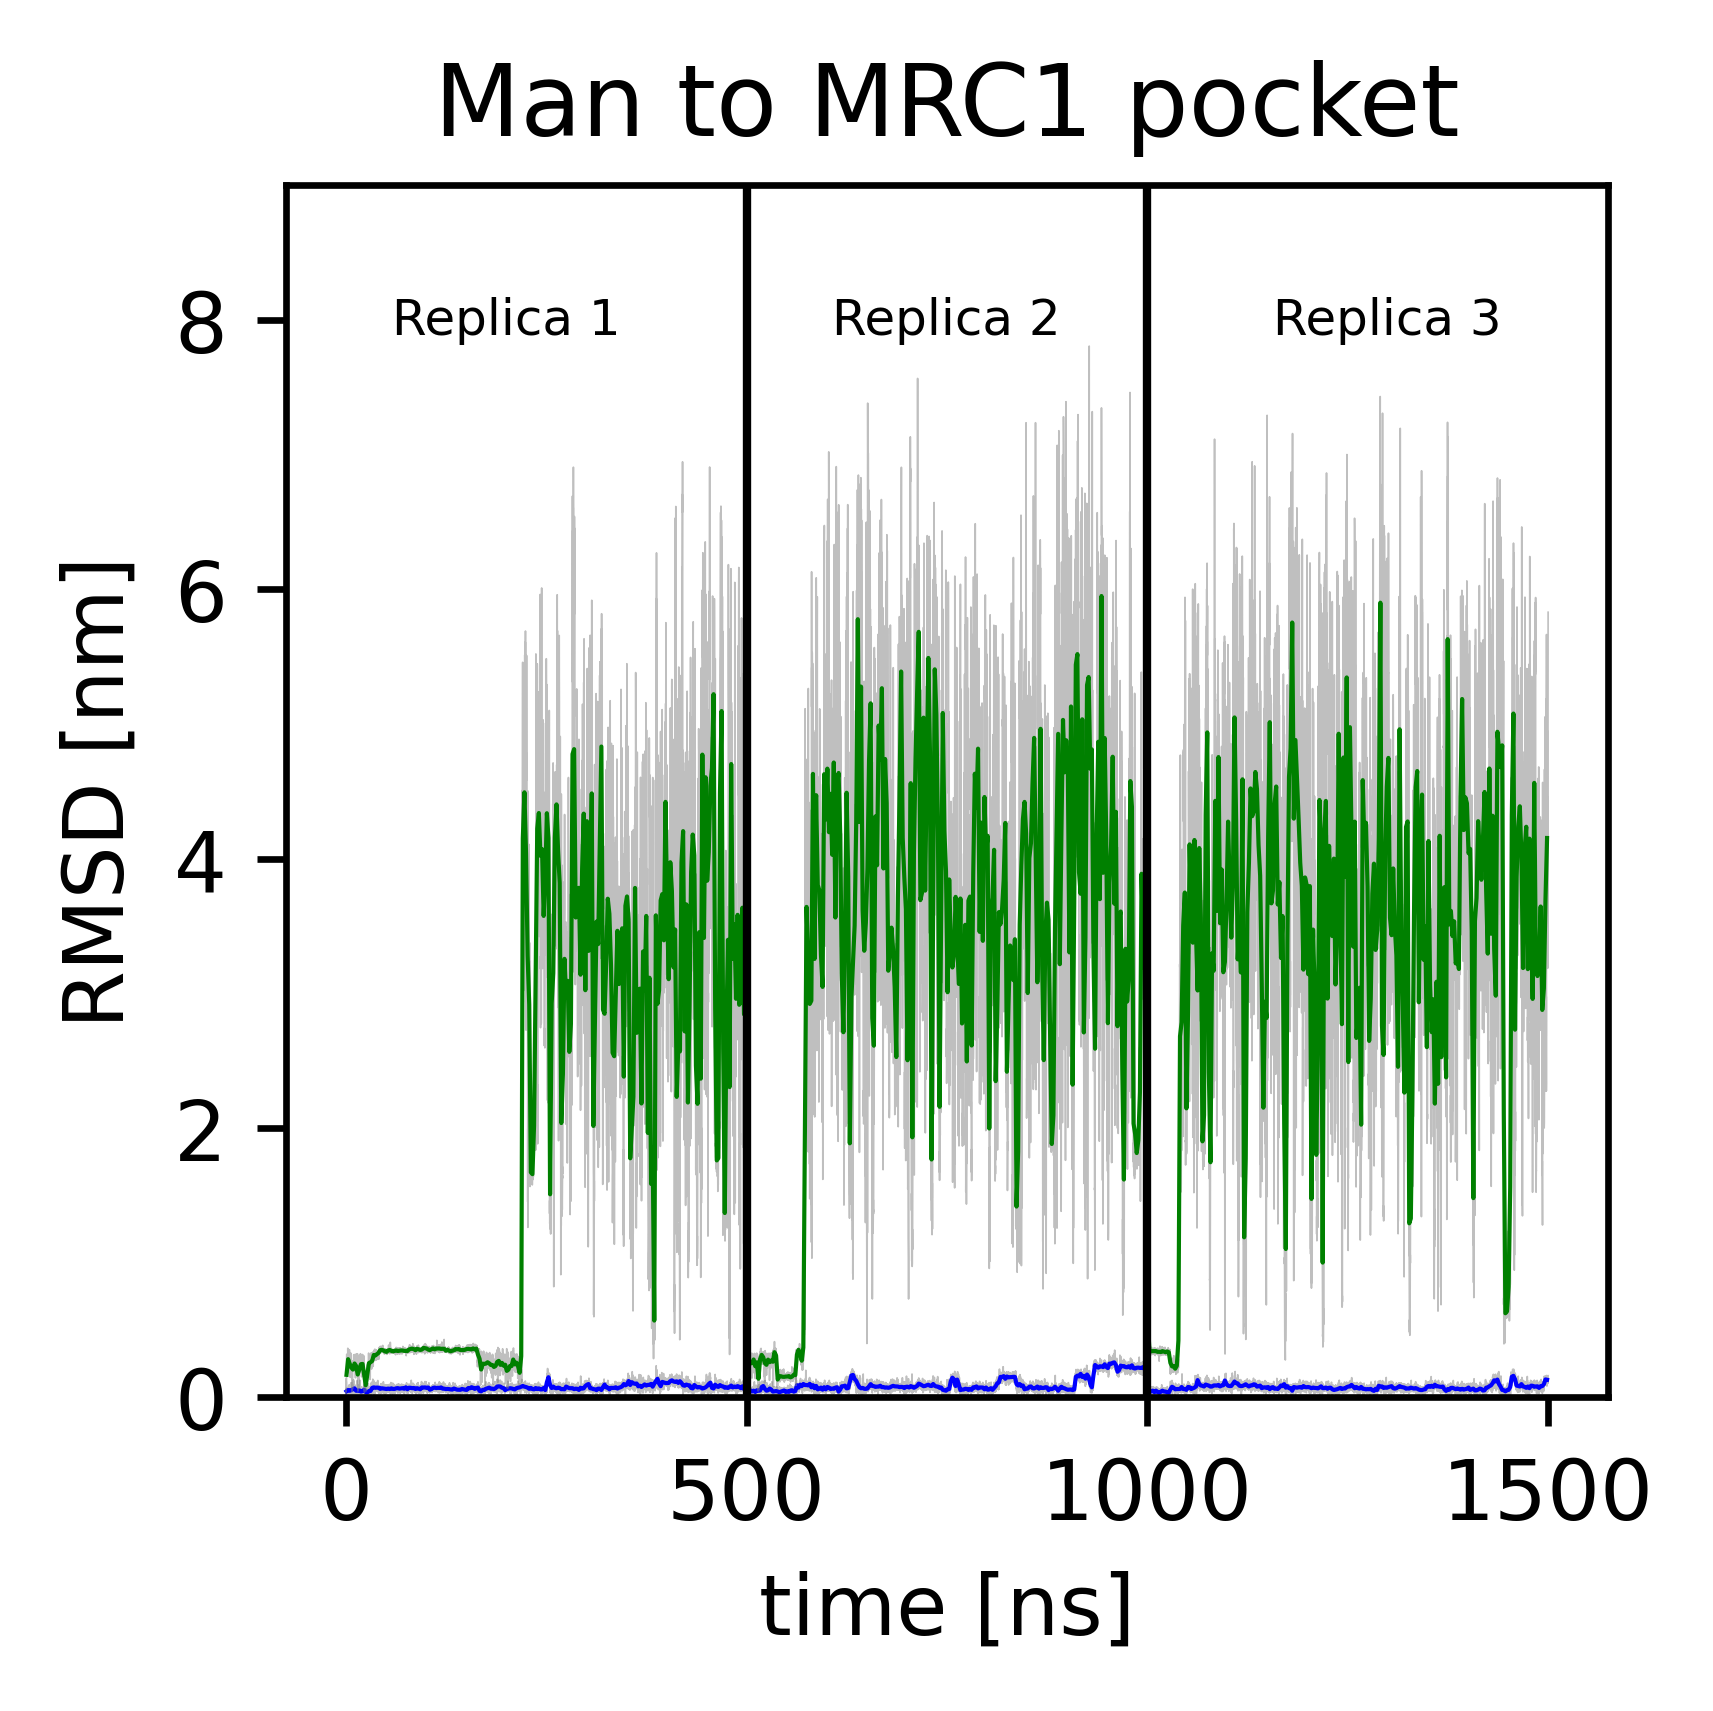

In [40]:
# plot RMSD
cm = 1/2.54
fig, ax = plt.subplots(figsize=(7.5*cm, 7.5*cm), dpi=600)

ax.plot(rmsd_cal_center.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD Cal
ax.plot(rmsd_cal_center[int(av/2-1):-int(av/2),0][::av]/1, rmean_cal[::av], linewidth=0.5, c='#0000FF') # smoothed RMSD Cal
ax.plot(rmsd_lig.T[1], linewidth=0.2, c='grey', alpha=0.5)  # RMSD lig
ax.plot(rmsd_lig[int(av/2-1):-int(av/2),0][::av]/1, rmean_lig[::av], linewidth=0.5, c='green') # smoothed RMSD lig
plt.axvline(5000, color='#000000', linewidth=1)  # borders between replica
plt.axvline(10000, color='#000000', linewidth=1)

plt.text(2000, 8, "Replica 1", size=6, rotation=0.,  # labels
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(7500, 8, "Replica 2", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))
plt.text(13000, 8, "Replica 3", size=6, rotation=0.,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec=(1, 1, 1),
                   fc=(1,1,1),))

ax.set_ylim(0,9)
# ax.set_xlim(0,15010)
plt.xticks([0, 5000, 10000, 15000,], ['0', '500', '1000', '1500',], fontsize=10)
plt.title('Man to MRC1 pocket')
ax.set_xlabel('time [ns]')
ax.set_ylabel('RMSD [nm]')
plt.tight_layout()
# plt.savefig("/data/geissler/analysis/RMSD/cal_lig/man-mrc.png")

## different binding states

Here I define the different binding conformations ("binding states") by distances of different mannose Hydroxy-groups to different amino acids in the binding pocket of the receptor: 
<br> 
(the different HO-groups are hightlighted in Fig.5 of the paper)
- the "crystal state" is defined by HO4 being close to Glu725, HO3 being close to Glu733, HO6 being far away from Glu737 and HO2 being far away from Glu725
- "state A" is defined by HO2 being close to Glu725, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu733
- "state B" is defined by HO2 being close to Glu733, HO4 being far from Glu725, HO6 being far from Glu737 and HO2 being far from Glu725
- "state C" is defined by HO6 being close to Glu737, HO3 being close to Glu733 and HO2 being far from Glu725 

In [3]:
# for the calculations I concatenated all frames of ligand being bound to the pocket
traj = mda.Universe(path_combined+'md_500ns.pdb',
                   path_combined+'combined_bound.xtc')

As I define the binding states by distances, I calculate the different distances between HO atoms and the respective amino acids

In [4]:
# this calculates the distance between the two defined atoms below for each frame of the simulation and appends them to a list
# distance 1: HO6 to Glutamic Acid 737
man = traj.select_atoms('resname AMAN and name HO6')
prot = traj.select_atoms('protein and resid 737 and name CD') 

distance1 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance1.append(dist_arr/10)  # convert from Angstr. to nm

In [5]:
# distance 2: HO2 to Glutamic Acid 725
man = traj.select_atoms('resname AMAN and name HO2')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance2 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance2.append(dist_arr/10)  # convert from Angstr. to nm

In [6]:
# distance 3: HO3 to Glutamic Acid 733
man = traj.select_atoms('resname AMAN and name HO3')
prot = traj.select_atoms('protein and resid 733 and name CD')

distance3 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance3.append(dist_arr/10)  # convert from Angstr. to nm

In [7]:
# distance 4: HO4 to Glutamic Acid 725 
man = traj.select_atoms('resname AMAN and name HO4')
prot = traj.select_atoms('protein and resid 725 and name CD')

distance4 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance4.append(dist_arr/10)  # convert from Angstr. to nm

In [8]:
# distance 5: HO2 to Glutamic Acid 733
man = traj.select_atoms('resname AMAN and name HO2')  
prot = traj.select_atoms('protein and resid 733 and name CD')

distance5 = []
R = np.zeros((man.atoms.n_atoms, prot.atoms.n_atoms))

for ts in traj.trajectory:
    dist_arr = distances.distance_array(man.positions,
                                       prot.positions,
                                       box=traj.dimensions,
                                       backend='OpenMP',
                                       result=R)
    distance5.append(dist_arr/10)  # convert from Angstr. to nm

In [9]:
# now I put them into 1 array
all_distances=np.column_stack((distance1,distance2,distance3,distance4,distance5))
# and make it flat
distances_flat=all_distances[:,:,0]
np.save('distances_flat.npy', distances_flat)

Now I sort the frames into their respective state. I defined the cutoff between close and far at 3.5 Ångström which roughliy corresponds to the length of a hydrogen bond.

In [10]:
# crystal state: HO4 close to Glu725, HO3 close to Glu733, HO6 far away from Glu737 and HO2 far away from Glu725
crystal = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][3] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        crystal.append(i)
print(len(crystal))  # print how many frames correspond to the crystal state

932


In [11]:
# state A: HO2 close to Glu725, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu733
stateA = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][1] <= 0.35 and distances_flat[i][3] > 0.35 and  distances_flat[i][0] > 0.35 and distances_flat[i][4] > 0.35:
        stateA.append(i)
print(len(stateA))

281


In [12]:
# state B: HO2 close to Glu733, HO4 far from Glu725, HO6 far from Glu737 and HO2 far from Glu725
stateB = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][4] <= 0.35 and distances_flat[i][3] > 0.35 and distances_flat[i][0] > 0.35 and distances_flat[i][1] > 0.35:
        stateB.append(i)
print(len(stateB))

430


In [13]:
# state C: HO6 close to Glu737, HO3 close to Glu733 and HO2 far from Glu725
stateC = []
for i, j in enumerate(distances_flat):
    if distances_flat[i][0] <= 0.35 and distances_flat[i][2] <= 0.35 and distances_flat[i][1] > 0.35:
        stateC.append(i)
print(len(stateC))

1247


In [14]:
# this is how I find out how many frames do not fall into any defined state ("others")
len(distances_flat)-len(crystal)-len(stateA)-len(stateB)-len(stateC)

423

## get frames of specific states to make a trajectory

For mmPBSA calculation for the specific states and for producing state contact maps, I will bin the frames of the same state together into one state specific trajectory. 
<br>
I will make trajectories between 100 and 300 frames, to have better comparability.
<br>
By multiplying the frame numbers with 100 ps and considering the order of replicas, I can use the output below directly as input for the 'states_trajectory.sh' bash script.

This is what the combined bound traj is made of:

- 1rep bound: 2191 frames, 219 ns, 219100 ps
- 2rep bound:  731 frames, 73 ns, 73100 ps
- 3rep bound:  391 frames, 39 ns, 39100 ps

  3313 frames in total -> 331300 ps

### crystal state

In [17]:
ps = 100
crystal_ps= [x*ps for x in crystal] 
print(*crystal_ps[:300])

0 100 200 300 400 500 600 700 800 900 1000 1300 1400 1500 1600 1700 1800 1900 2000 2100 2200 2400 2600 2700 3000 3200 3600 3900 4000 4100 4200 4700 4800 5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6400 6500 6600 6700 6800 6900 7000 7100 7200 7300 7400 7600 7700 7800 7900 8000 8100 8200 8300 8400 8500 8600 8700 8800 8900 9000 9100 9400 9700 10400 10500 10700 10900 11000 11100 11200 11300 11400 11500 11600 11700 11800 11900 12000 12100 12200 12300 12400 12500 12600 12700 12800 12900 13100 13200 13400 13500 13600 13700 13900 14000 14100 14200 14700 14800 14900 15000 15100 15200 15300 15400 15500 15600 15700 15800 15900 16000 16100 16200 16300 16400 16500 16600 16700 16800 17000 17100 17200 17300 17400 17700 17800 17900 18000 18100 18200 18400 18500 18700 18800 18900 19000 19100 19200 19300 19400 19500 19600 19700 19800 19900 20000 20100 20200 20300 20400 20500 20600 20800 21000 21200 21300 21500 21600 21700 21800 22100 22200 22300 22400 22600 22700 22800 22900 23000 2

The first 300 frames are all in replica 1.

### state A

In [18]:
ps = 100
stateA_ps= [x*ps for x in stateA] 
print(*stateA_ps[:300])

292700 292800 292900 293000 293100 293200 293300 293400 293500 293600 293700 293800 293900 294000 294100 294200 294300 294400 294500 294600 294700 294800 294900 295000 295100 295300 295400 295500 295600 295700 295800 295900 296000 296100 296200 296300 296400 296500 296600 296700 296800 296900 297000 297100 297200 297300 297500 297600 297700 297800 297900 298000 298100 298200 298300 298400 298500 298600 298700 298800 298900 299000 299100 299200 299300 299400 299500 299600 299700 299800 299900 300000 300100 300200 300300 300400 300500 300600 300700 300800 300900 301000 301100 301200 301300 301400 301500 301600 301800 301900 302000 302100 302200 302300 302400 302500 302600 302700 302800 302900 303000 303100 303200 303300 303400 303500 303600 303700 303800 303900 304000 304100 304200 304300 304400 304500 304600 304700 304800 304900 305000 305100 305200 305300 305400 305500 305600 305700 305800 305900 306000 306200 306300 306400 306500 306600 306700 306800 306900 307000 307100 307200 307300

In [19]:
print('frames in 1rep:')
for i in stateA_ps[:300]:
    if i <= 219100:
        print(i)

frames in 1rep:


In [20]:
print('frames in 2rep:')
for i in stateA_ps[:300]:
    if i > 219100 and i <= (73100+219100):
        print(i-219100)

frames in 2rep:


In [21]:
print('frames in 3rep:')
for i in stateA_ps[:300]:
    if i > (73100+219100):
        print(i-(73100+219100))

frames in 3rep:
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19300
1

### state B

In [27]:
ps = 100
stateB_ps= [x*ps for x in stateB] 
print(*stateB_ps[:300])

1100 1200 2300 2500 2800 2900 3100 3300 3400 3500 3700 3800 4300 4400 4500 4600 4900 6300 7500 9200 9300 9500 9600 9800 9900 10000 10100 10200 10300 10600 10800 13000 13300 13800 14300 14400 14500 14600 16900 17500 17600 18300 18600 20700 20900 21100 21400 21900 22000 22500 28400 28500 28600 28700 28800 28900 29000 29700 30200 30300 30600 30800 31000 31100 31200 31300 31600 31700 31800 31900 32000 32100 32300 32600 32900 33000 33300 33400 33500 33600 33700 33900 34000 34300 34400 34500 34600 34700 34800 34900 35000 35100 35200 36800 36900 37000 37100 37200 37300 37400 37500 37700 37800 37900 38000 38100 38200 38300 38400 38500 38600 38700 38800 38900 39000 39100 39200 39300 39500 39600 39700 39900 40000 40100 40200 40300 40400 40500 40600 40700 40800 40900 41000 75800 134600 164500 164600 164700 164800 164900 165000 165100 165200 165600 165700 165800 166100 166300 166500 166600 166800 167100 169200 169300 169500 170100 170500 170700 171100 171700 171900 172000 172300 172400 173000 1732

In [23]:
print('frames in 1rep:')
for i in stateB_ps[:300]:
    if i <= 219100:
        print(i)

frames in 1rep:
1100
1200
2300
2500
2800
2900
3100
3300
3400
3500
3700
3800
4300
4400
4500
4600
4900
6300
7500
9200
9300
9500
9600
9800
9900
10000
10100
10200
10300
10600
10800
13000
13300
13800
14300
14400
14500
14600
16900
17500
17600
18300
18600
20700
20900
21100
21400
21900
22000
22500
28400
28500
28600
28700
28800
28900
29000
29700
30200
30300
30600
30800
31000
31100
31200
31300
31600
31700
31800
31900
32000
32100
32300
32600
32900
33000
33300
33400
33500
33600
33700
33900
34000
34300
34400
34500
34600
34700
34800
34900
35000
35100
35200
36800
36900
37000
37100
37200
37300
37400
37500
37700
37800
37900
38000
38100
38200
38300
38400
38500
38600
38700
38800
38900
39000
39100
39200
39300
39500
39600
39700
39900
40000
40100
40200
40300
40400
40500
40600
40700
40800
40900
41000
75800
134600
164500
164600
164700
164800
164900
165000
165100
165200
165600
165700
165800
166100
166300
166500
166600
166800
167100
169200
169300
169500
170100
170500
170700
171100
171700
171900
172000
172300
17

In [28]:
print('frames in 2rep:')
for i in stateB_ps[:500]:
    if i > 219100 and i <= (73100+219100):
        print(i-219100)

frames in 2rep:
2200
2500
3100
4100
4200
4400
4500
4700
6500
7500
7600
7700
7800
7900
8300
8400
8600
9000
9100
9200
9300
9400
9500
9600
9700
9900
10000
10400
11600
12000
12100
12300
12400
12500
12700
13500
13700
16100
16300
16900
17200
17300
17400
17500
17900
18000
18100
18200
18300
18400
18500
18600
18700
18800
18900
19000
19100
19200
19400
19600
19700
19800
19900
20000
20100
20300
20400
20500
20600
20700
21100
21200
21300
21400
21500
21600
21700
21800
21900
23000
23100
23200
23500
23700
24100
24600
25100
25500
25800
26000
26100
26300
26400
26500
26800
26900
27000
27400
27500
27600
27800
28000
28100
28200
28300
29000
29200
29300
29500
29900
30600
30700
31100
31200
31400
31600
31700
31800
32100
32200
32300
32400
32700
32800
33000
33100
33200
33500
33800
34000
34100
34200
34300
34400
34700
34800
34900
35000
35100
35200
35300
35400
35500
35600
35700
35800
35900
36000
36100
36200
36300
36400
36500
36600
36700
36800
36900
37000
37100
37400
37600
61900
62100
62200
62300
62400
62500
62600
62

In [25]:
print('frames in 3rep:')
for i in stateB_ps[:300]:
    if i > (73100+219100):
        print(i-(73100+219100))

frames in 3rep:


### state C

In [29]:
ps = 100
stateC_ps= [x*ps for x in stateC] 
print(*stateC_ps[:300])

35300 35400 35500 35600 35700 35800 35900 36000 36100 36200 41200 41300 41400 41500 41600 41800 41900 42000 42100 42200 42300 42400 42500 42600 42700 42800 42900 43000 43100 43200 43300 43400 43500 43600 43700 43800 43900 44000 44100 44200 44300 44400 44500 44600 44700 44800 44900 45000 45100 45200 45300 45400 45500 45600 45700 45800 45900 46000 46100 46200 46300 46400 46500 46600 46700 46800 46900 47000 47100 47200 47300 47400 47500 47600 47700 47800 47900 48000 48100 48200 48300 48400 48500 48600 48700 48800 48900 49000 49100 49200 49300 49400 49500 49600 49700 49800 49900 50000 50100 50200 50300 50400 50500 50600 50700 50800 50900 51000 51100 51200 51300 51400 51500 51600 51700 51800 51900 52000 52100 52200 52300 52400 52500 52600 52700 52800 52900 53000 53100 53200 53300 53400 53500 53600 53700 53800 53900 54000 54100 54200 54300 54400 54500 54600 54700 54800 54900 55000 55100 55200 55300 55400 55800 55900 56100 56200 56300 56400 56500 56600 56700 56800 56900 57200 57300 57400 5750

The first 300 frames are all in replica 1.